#Question 1: Ideal Gas Law and Isotherms


---


###Part (a):
Create a function that takes temperature (in Kelvin) and volume (in m3) as input and returns pressure (in
Pa) as output. Use the ideal gas law: PV = nRT, where n = 1 mole and R = 8.314 J/(mol·K).

Note: All units must be in the SI (metric) system.



---


###Part (b):
Create an array of volumes containing natural numbers from 1 to 50 (representing m3). Using the function
from part (a), plot two isotherms (temperature = 273 K and temperature = 323 K) on the same graph. The
x-axis should represent volume (V in m3) and the y-axis should represent pressure (P in Pa).


Requirements: Include axis labels, a title, and a legend to identify each isotherm.

In [ ]:
#PART (a):
# we define a function using the ideal gas law
def calculate_pressure(temp, vol):
  R = 8.314  # Gas constant(J/(mol·K))
  n = 1      # moles
  pressure = (n * R * temp) / vol  # rearranging the equation
  return pressure

# taking inputs
temp = float(input('Enter the temperature (in kelvin):' ))
vol = float(input('Enter the volume (in m^3):' ))

# final output
print('The pressure is:', calculate_pressure(temp, vol), 'Pa')

Enter the temperature (in kelvin):373
Enter the volume (in m^3):50
The pressure is: 62.022439999999996 Pa


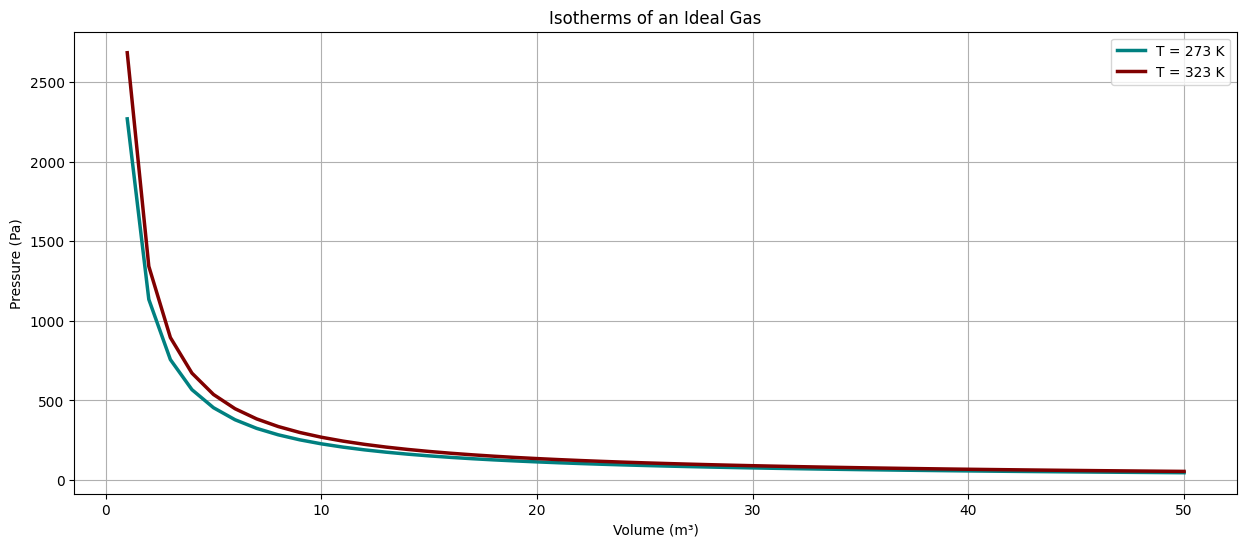

In [ ]:
#PART (b):
#importing essential libraries
import numpy as np
import matplotlib.pyplot as plt

#create a numpy array from 1 to 50
volumes = np.arange(1,51)

#temperatures to be plotted and the pressures and related volumes
T1 = 273
T2 = 323
pressure_273 = calculate_pressure(T1, volumes)
pressure_323 = calculate_pressure(T2, volumes)

#plotting!
plt.figure(figsize=(15, 6))

plt.plot(volumes, pressure_273,color = 'teal', linewidth = 2.5, label="T = 273 K")
plt.plot(volumes, pressure_323,color = 'maroon', linewidth = 2.5, label="T = 323 K")
plt.xlabel("Volume (m³)")
plt.ylabel("Pressure (Pa)")
plt.title("Isotherms of an Ideal Gas")
plt.legend()
plt.grid(True)

plt.show()

#Question 2: Understanding Data Distribution with Random Arrays


---


###Part (a):
Create three different random arrays using a uniform distribution between -100 and +100:

(i) Array with 10 elements


(ii) Array with 100 elements


(iii) Array with 1000 elements



---


###Part (b):
For each of the three arrays, plot a histogram by dividing the data into 1000 equal intervals (bins). You
should have three separate histograms.


---


###Part (c):
Write an explanation of the results from part (b) in a Markdown cell.

Discuss:

* How the shape of the histogram changes as the number of data points increases
* Why a uniform distribution should look flat (or nearly flat) across all bins
* How randomness affects the appearance of small vs. large datasets

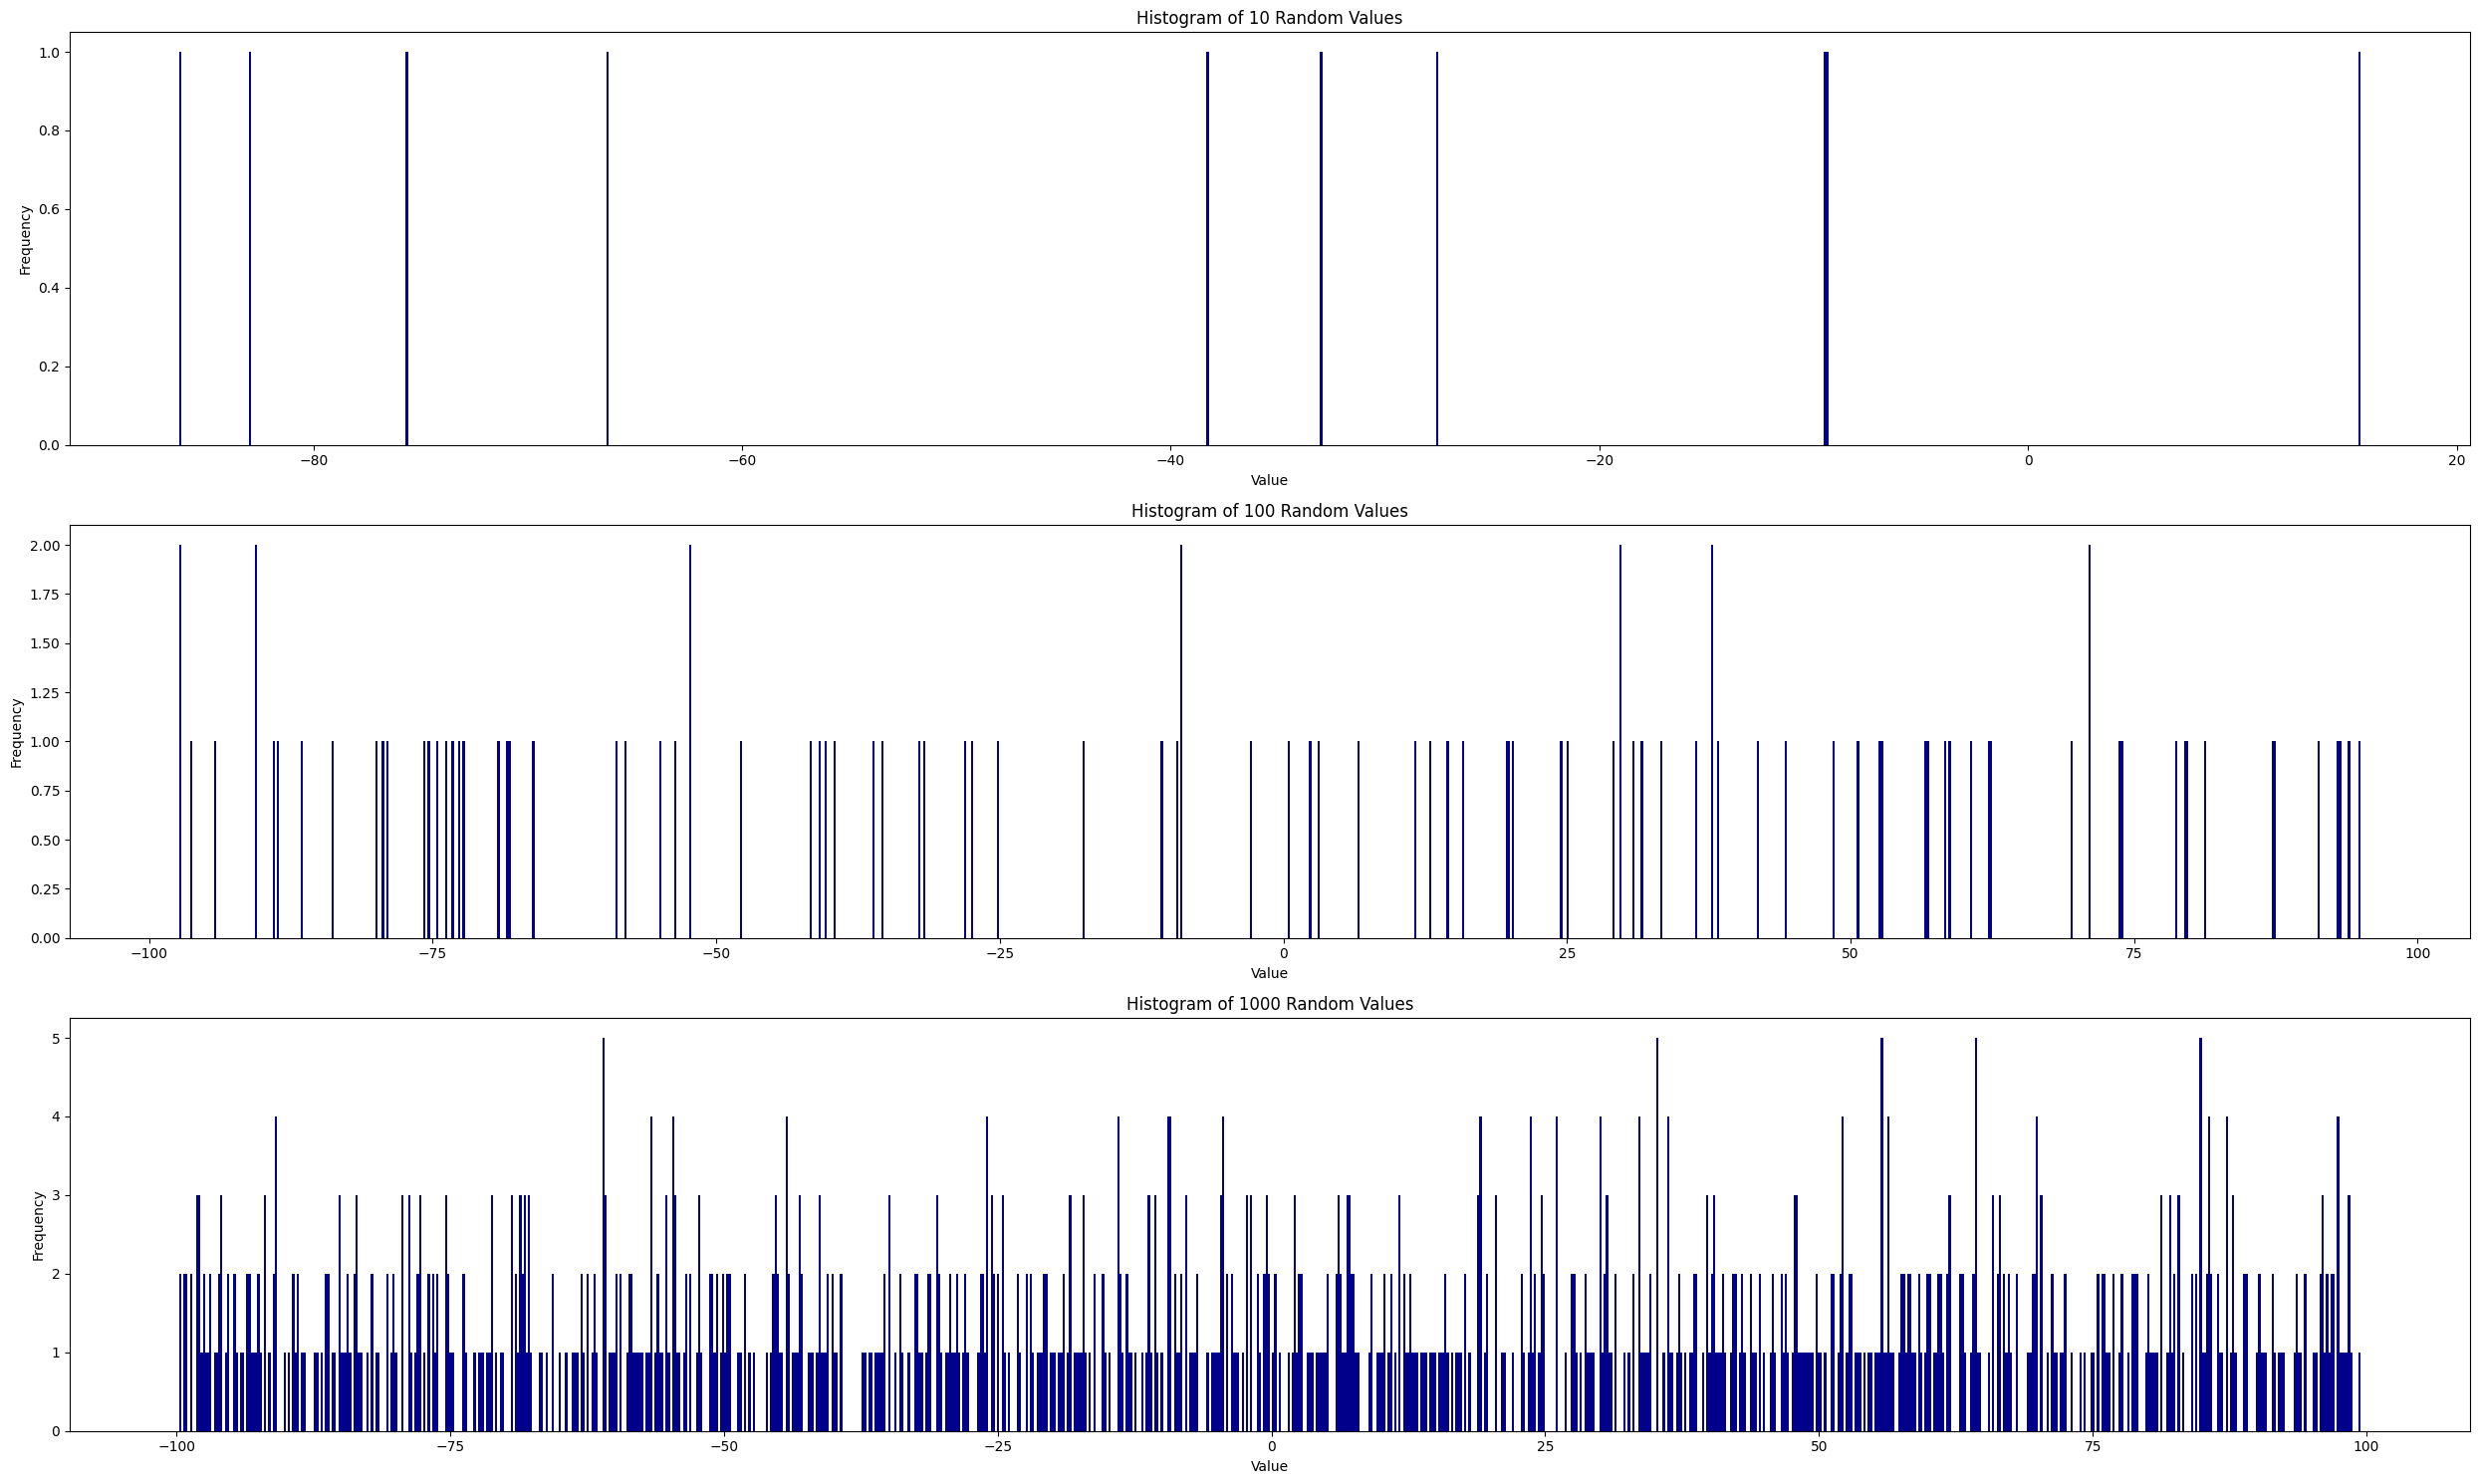

In [ ]:
#PART (a):
#importing essential libraries
import numpy as np
import matplotlib.pyplot as plt

array_10 = np.random.uniform(-100,100,10)
array_100 = np.random.uniform(-100,100,100)
array_1000 = np.random.uniform(-100,100,1000)

#PART (b):
fig, axes = plt.subplots(3 , 1, figsize= (25,15))

axes[0].hist(array_10, bins = 1000, color = 'darkblue')
axes[0].set_title("Histogram of 10 Random Values")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Frequency")

axes[1].hist(array_100, bins = 1000, color = 'darkblue')
axes[1].set_title("Histogram of 100 Random Values")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Frequency")

axes[2].hist(array_1000, bins = 1000, color = 'darkblue')
axes[2].set_title("Histogram of 1000 Random Values")
axes[2].set_xlabel("Value")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## Explanation of Results

### Effect of Number of Data Points
- **10 elements**: The histogram looks very irregular and sparse. Random fluctuations dominate the appearance of graph.
- **100 elements**: The distribution starts to look more uniform, but small fluctuations are still visible.
- **1000 elements**: The histogram is much smoother, closely resembling a flat distribution.

### Why a Uniform Distribution Looks Flat
- In a uniform distribution, all values in the range [-100, 100] are equally likely to occur.
- Therefore, with a large number of data points, all bins have approximately the same frequency, giving a flat or nearly flat histogram.

### Effect of Randomness
- **Small datasets** show large variations due to randomness; some bins may have zero or multiple counts.
- **Large datasets** average out random fluctuations, revealing the true uniform nature of the distribution.


#Question 3: Variable Thermal Conductivity (Class-based Approach)


---


###Part (a):

Assume a hypothetical rod where the specific thermal conductivity varies with position according to:
k(x) = ax + d, where a = 1, d = 1, and both are greater than zero.
Create a Python class called ThermalRod that:
* Stores the values of a and d in the __init__ method
* Has a method called get_temperature(x) that takes position x (in meters) as input and returns the temperature T(x) as output

* Assumes the boundary condition: T(0) = 0 K (temperature at the left end is 0)
* Uses numerical integration (via SciPy) to calculate the temperature at any position

Hint: The temperature at any point equals the total temperature difference multiplied by the ratio of
thermal resistance between that point and the coldest point to the total thermal resistance of the rod.


---


###Part (b):
Generate x-values from 0 to 1 meter with a resolution of 1 cm (0.01 m) and plot the Temperature vs Position graph using the class method from part (a).

Given Parameters:
* Length of rod = 1 m
* a = 1
* d = 1

In [ ]:
#PART (b):
import numpy as np
from scipy.integrate import quad

class ThermalRod:
    def __init__(self, a=1, d=1, length=1, T_hot=100):
        self.a = a
        self.d = d
        self.length = length
        self.T_hot = T_hot  # Total temperature difference across rod

    def k(self, x):
        return self.a * x + self.d

    def thermal_resistance(self, x1, x2):
        integrand = lambda x: 1 / self.k(x)
        R, _ = quad(integrand, x1, x2)
        return R

    def get_temperature(self, x):
        R_total = self.thermal_resistance(0, self.length)
        R_x = self.thermal_resistance(0, x)
        return self.T_hot * (R_x / R_total)

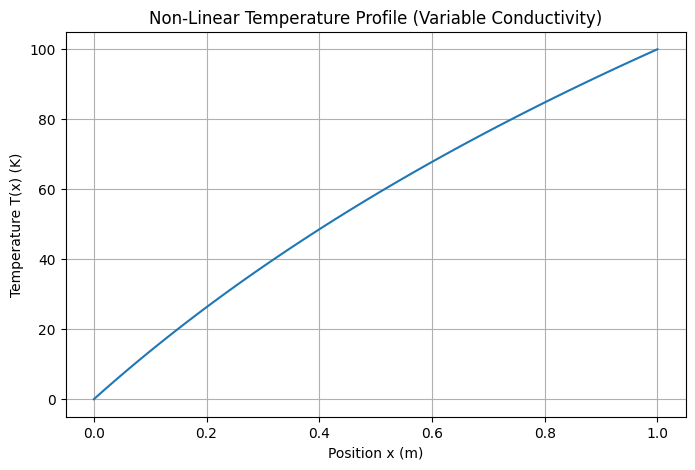

In [ ]:
#PART (b):
import matplotlib.pyplot as plt

rod = ThermalRod(a=1, d=1, length=1, T_hot=100)

x_vals = np.arange(0, 1.01, 0.01)
T_vals = [rod.get_temperature(x) for x in x_vals]

plt.figure(figsize=(8, 5))
plt.plot(x_vals, T_vals)
plt.xlabel("Position x (m)")
plt.ylabel("Temperature T(x) (K)")
plt.title("Non-Linear Temperature Profile (Variable Conductivity)")
plt.grid(True)
plt.show()

#Question 4: Heat Transfer and Phase Change (Calorimetry)

---


###Part (a):

Create a dictionary where:
* Keys = Material names (e.g., 'water', 'iron', 'copper', 'aluminum')
* Values = Specific heat capacities in J/(kg·K)

 Use the following data:
* Water: 4180 J/(kg·K)
* Iron: 483 J/(kg·K)
* Copper: 399 J/(kg·K)
* Aluminum: 882 J/(kg·K)


---


###Part (b):
Create a function that simulates the mixing of hot water with ice. The function takes:
* M = mass of hot water (in kg)
* T = initial temperature of water (in °C)
* m = mass of ice (in kg) at the freezing point (0°C)

The function should return:
* If ice does NOT completely melt: The mass of ice that melted (in kg)
* If ice does completely melt: The final equilibrium temperature (in °C) of the mixture

Given Parameters:
* Latent heat of fusion of ice = 334 kJ/kg = 334,000 J/kg
* Specific heat of water = 4180 J/(kg·K)

* Neglect the heat capacity of the tumbler (container)

Physics Formula to Use:

Qlost by water = Qgained by ice

Where:
* Heat lost by water = M ⋅ cwater ⋅ (T − Tf)
* Heat to melt ice = mmelted × Lf

In [ ]:
#PART (a):
specific_heat = {
    "water": 4180,     # J/(kg·K)
    "iron": 483,
    "copper": 399,
    "aluminum": 882
}

In [ ]:
#PART (b):
def mix_water_and_ice(M, T, m):
    c = 4180              # J/(kg·K)
    Lf = 334000           # J/kg

    # Heat available from hot water cooling to 0°C
    Q_available = M * c * T

    # Heat required to melt all the ice
    Q_melt_all = m * Lf

    if Q_available < Q_melt_all:
        # Ice does NOT completely melt
        melted_mass = Q_available / Lf
        return melted_mass
    else:
        # Ice completely melts
        Q_remaining = Q_available - Q_melt_all

        # Total water mass after melting
        total_mass = M + m

        # Final equilibrium temperature
        Tf = Q_remaining / (total_mass * c)
        return Tf


In [ ]:
#Testing the function
print(mix_water_and_ice(0.5, 20, 0.2))
print(mix_water_and_ice(0.3, 30, 0.1))
print(mix_water_and_ice(1.0, 50, 0.1))

0.1251497005988024
2.5239234449760763
38.19051761635494
